# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Three trials are recorded. Best is trial_03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) at objective 0.1040 (0 diverged, gamma finite on all 8; mu rel-RMSE 45.8%, gamma rel-RMSE 23.3%) - the first result below the experiment_5 honest level (~0.108-0.113) and the 0.1074 headline. trial_01 (sw 0.409, h_s 3.354, h_f 1.837, cap 0.156) is 0.1243 and trial_02 (sw 0.884, h_f 0.642, h_s 1.007, cap 0.054) is 0.1287. The best region so far combines flat kernels (h_f ~2.4, h_s ~3.0) with a strong sigma link (sw ~0.96). Still in the uniform phase (3/5 completed), so the candidates below are independent random draws.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"gamma_rel_cap": 0.4715280527861838, "h_f_scale": 2.1674783230538557, "h_s_scale": 3.9109138964038905, "sigma_weight": 0.08083602389560218}
 2 |      - | {"gamma_rel_cap": 0.3036779159975148, "h_f_scale": 1.661824691414772, "h_s_scale": 3.257129526196777, "sigma_weight": 0.17452781614402846}
 3 |      - | {"gamma_rel_cap": 0.4358176370938282, "h_f_scale": 2.2897802528631184, "h_s_scale": 3.6333065489349563, "sigma_weight": 0.4771535238392063}
 4 |      - | {"gamma_rel_cap": 0.21524813886470656, "h_f_scale": 3.2085501907912355, "h_s_scale": 3.9405737497417053, "sigma_weight": 0.3697257926524288}
 5 |      - | {"gamma_rel_cap": 0.48446643465811745, "h_f_scale": 3.733848954120323, "h_s_scale": 0.9163471966074291, "sigma_weight": 0.6088516168445476}
 6 |      - | {"gamma_rel_cap": 0.3524323727823713, "h_f_scale": 3.785513796734377, "h_s_scale": 2.7462153136215752, "sigma_weight": 0.13339575545169313}
 7 |      - | {"gamma_re

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Registry: trial_03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) is best at 0.1040 and defines a productive region of flat kernels with a strong sigma link; trial_01 (0.1243, sw 0.409) and trial_02 (0.1287, sharp h_f 0.64) are worse. Low-sw flat-kernel combinations have already been sampled (trial_01), so a further low-sw draw adds little. Uniform phase (3/5): all candidates are random draws with ei = '-'.

Candidate 7 (sw 0.959, h_f 2.101, h_s 2.126, cap 0.249) matches the best point's sigma weight almost exactly and its FWHM kernel closely, differing mainly in the sigma kernel bandwidth (h_s 2.13 vs 3.02) and a slightly larger gamma cap. It is the clearest one-knob perturbation of trial_03's configuration present in this batch, so it isolates the sensitivity of h_s inside the productive region.

I choose candidate 7.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7               # candidate 7: sigma_weight 0.959, h_f_scale 2.101, h_s_scale 2.126, gamma_rel_cap 0.249 (near-best, lower h_s)


chosen: {'gamma_rel_cap': 0.24893379939268723, 'h_f_scale': 2.101074377335431, 'h_s_scale': 2.125848210057797, 'sigma_weight': 0.9585822861092472}
Running  1nW Trans05 ... 

μ 9.39 -> 7.61 | γ 8.5 -> 3.28 | NLL 0.86


Running  1nW Trans20 ... 

μ 17.32 -> 34.81 | γ 8.5 -> 6.03 | NLL 1.79


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 69.37 | γ 14.1 -> 14.25 | NLL 1.48


Running 3nW Trans100 ... 

μ 175.71 -> 101.68 | γ 14.1 -> 13.98 | NLL 1.49



Total: 7.4 min


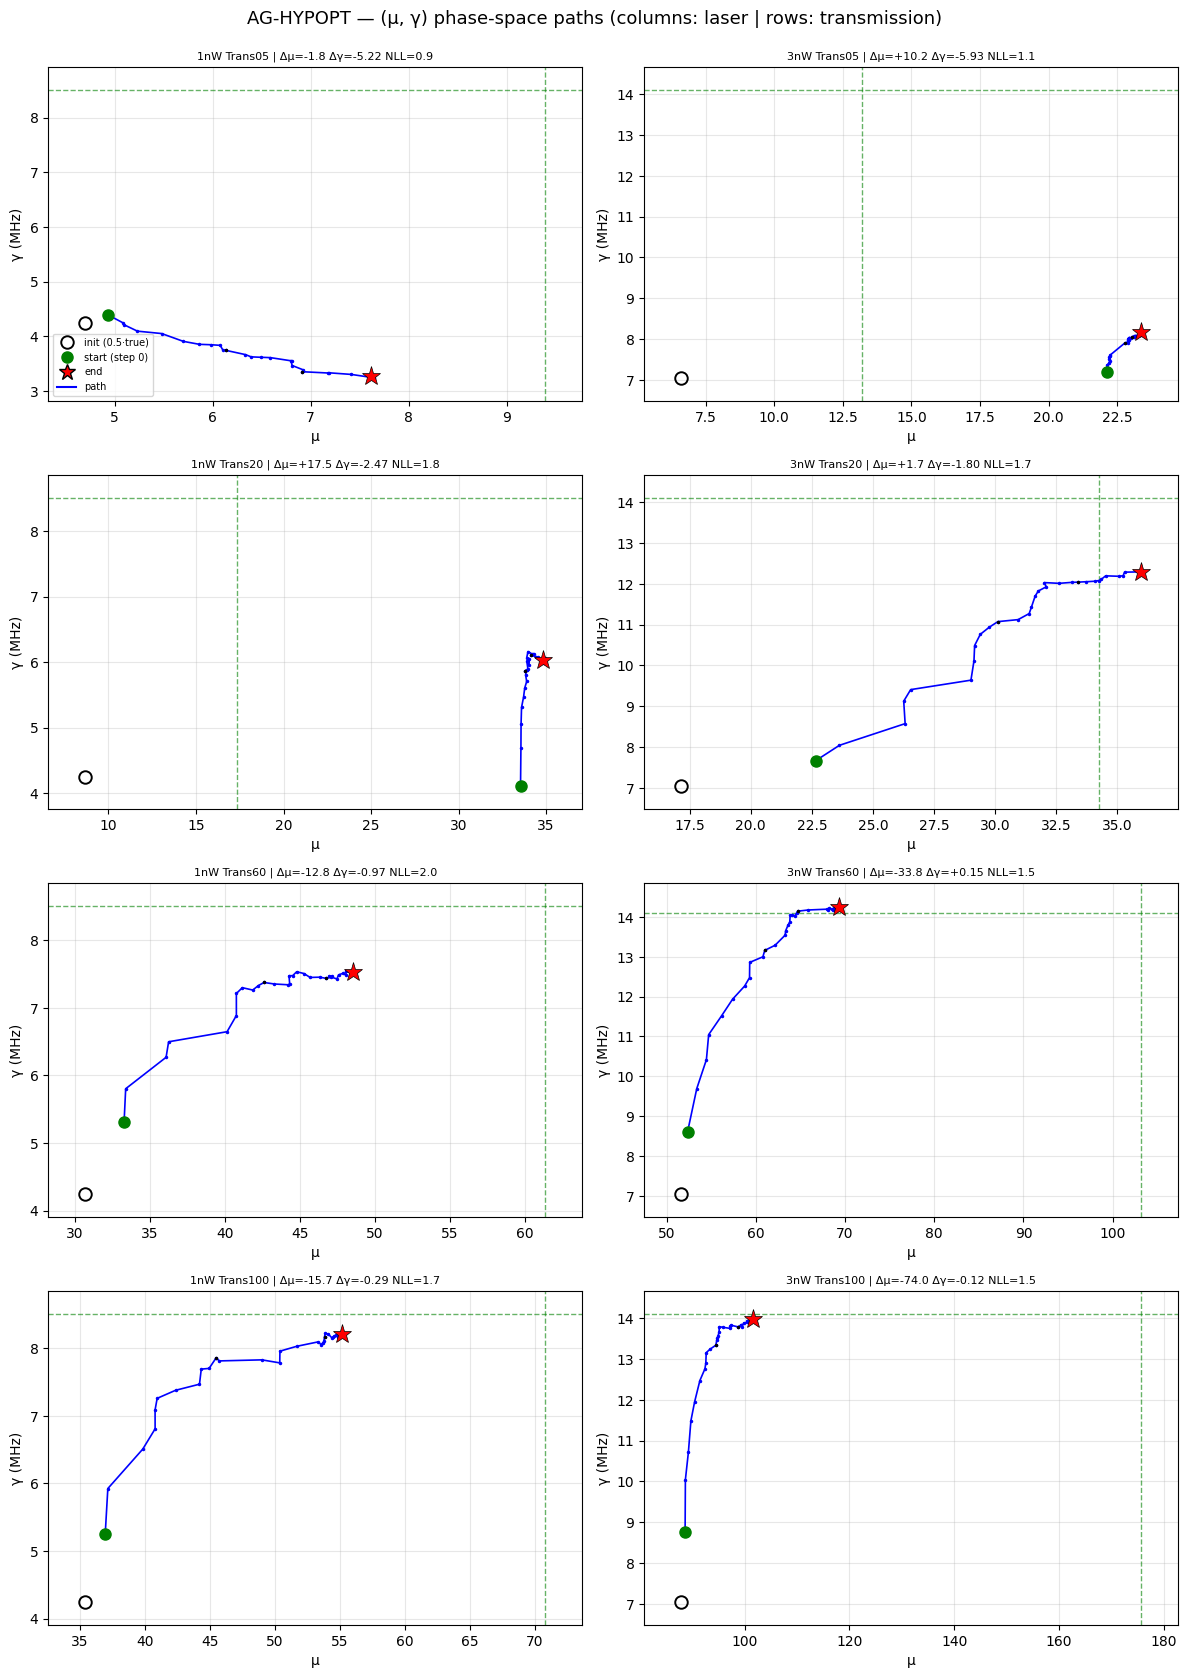

trial finished in 7.4 min
objective = 0.1177 ± 0.0687
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    7.61   -19.0 |     8.50    3.28   -61.4
1nW Trans20       17.32   34.81  +101.0 |     8.50    6.03   -29.0
1nW Trans60       61.37   48.53   -20.9 |     8.50    7.53   -11.5
1nW Trans100       70.82   55.15   -22.1 |     8.50    8.21    -3.4
3nW Trans05       13.20   23.37   +77.0 |    14.10    8.17   -42.1
3nW Trans20       34.28   35.99    +5.0 |    14.10   12.30   -12.8
3nW Trans60      103.20   69.37   -32.8 |    14.10   14.25    +1.1
3nW Trans100      175.71  101.68   -42.1 |    14.10   13.98    -0.8

weighted objective (T-graded, cap=1.0) = 0.1177 | diverged cells: 0
μ: RMSE 30.519 (rel 50.4%, bias -13.599) | γ: RMSE 3.017 (rel 28.9%, bias -2.082)


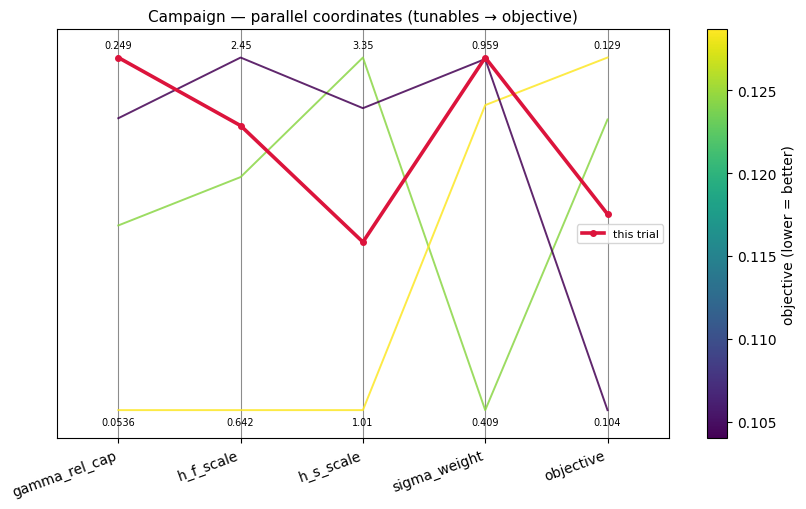

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 04 (sw 0.959, h_f 2.101, h_s 2.126, cap 0.249) ran to completion in 7.4 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.1177 +/- 0.0687 - worse than the best trial_03 (0.1040), but still the second best so far, ahead of trial_01 (0.1243) and trial_02 (0.1287).

mu rel-RMSE 50.4%: the same shape as before - overshoot at low T (1nW Trans20 +101.0%, 3nW Trans05 +77.0%) and undershoot at high T (3nW Trans100 -42.1%, 3nW Trans60 -32.8%, 1nW Trans100 -22.1%, 1nW Trans60 -20.9%); bias -13.60.

gamma rel-RMSE rose to 28.9% (vs 23.3% in trial_03), driven mostly by low T (1nW Trans05 -61.4%, 3nW Trans05 -42.1%, 1nW Trans20 -29.0%); high T stayed recovered (+1.1%, -0.8%, -3.4%).

Interpreting the choice: candidate 7 was intended as a one-knob perturbation of trial_03, but it in fact lowered both kernels' flatness (h_f 2.450 -> 2.101 and h_s 3.017 -> 2.126) while holding sw ~0.96; the objective worsened from 0.1040 to 0.1177, so at least one of the two kernel flatnesses matters, and neither sharpening helped.

**Summary:** Trial 04 (sw=0.959, h_f=2.101, h_s=2.126, cap=0.249) finished in 7.4 min with 0 diverged cells and gamma finite, objective 0.1177 +/- 0.0687 - second best, worse than trial_03's 0.1040 (mu rel-RMSE 50.4%, gamma rel-RMSE 28.9%).
**Key insight:** Sharpening both KDE kernels (h_f 2.45->2.10, h_s 3.02->2.13) from the best point raised the objective 0.1040->0.1177, so the flatness of the kernels, not the sigma weight, drives trial_03's advantage.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 04 (sw=0.959, h_f=2.101, h_s=2.126, cap=0.249): objective 0.1177 +/- 0.0687 - second best, worse than trial_03; 0 diverged cells, gamma finite (mu rel-RMSE 50.4%, gamma rel-RMSE 28.9%).'
KEY_INSIGHT = 'Sharpening both KDE kernels (h_f 2.45->2.10, h_s 3.02->2.13) from the best point raised the objective 0.1040->0.1177, so kernel flatness rather than the sigma weight drives trial_03 advantage.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_03


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
